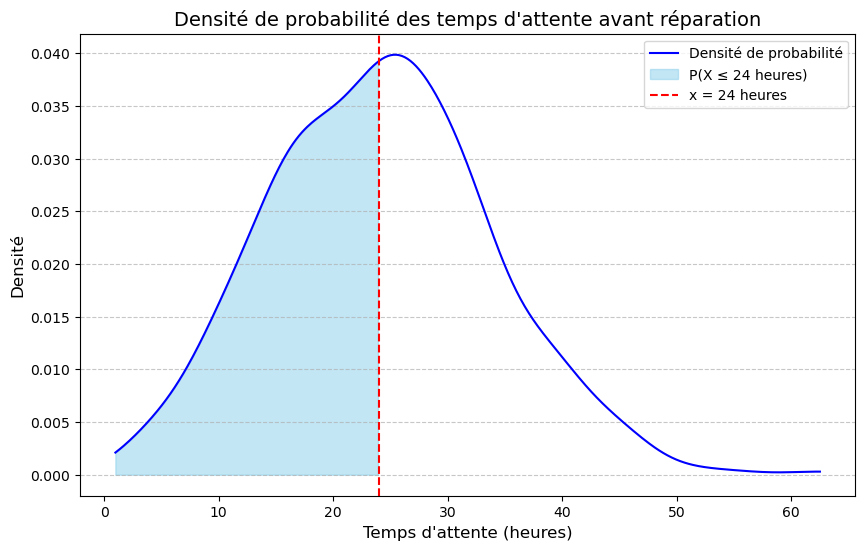

Proportion des réparations en moins de 24 heures : 49.52%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Charger les données depuis le fichier Excel
file_path = r"C:\Users\Mediamonster\Downloads\Forment_Fotso_Modelisation_OR_Python\Introduction\Temps_attent_panneServeur_Densite.xlsx"
data = pd.read_excel(file_path)

# Extraction des temps d'attente en heures
temps_attente = data["Temps d'attente (heures)"].values

# Calcul de la densité de probabilité
density = gaussian_kde(temps_attente)
x_vals = np.linspace(temps_attente.min(), temps_attente.max(), 500)
density_vals = density(x_vals)

# Création du graphique de densité
plt.figure(figsize=(10, 6))
plt.plot(x_vals, density_vals, color='blue', label='Densité de probabilité')
plt.fill_between(x_vals, density_vals, where=(x_vals <= 24), color='skyblue', alpha=0.5, label='P(X ≤ 24 heures)')
plt.axvline(24, color='red', linestyle='--', label='x = 24 heures')
plt.title("Densité de probabilité des temps d'attente avant réparation", fontsize=14)
plt.xlabel("Temps d'attente (heures)", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calcul de la proportion des réparations en moins de 24 heures
proportion_moins_24 = density.integrate_box_1d(0, 24)
print(f"Proportion des réparations en moins de 24 heures : {proportion_moins_24:.2%}")
